# Welcome to Biotechnology Research Fellowship Program (BRFP)
## Track 3: Molecular Modeling in Structural Biology

**Instructor:** Dr. [Yanxing Yang](mailto:yayang@caldwell.edu)  
**Lab Assistants:** [Kushma Saud](ksaud@caldwell.edu) & [Nabin Oli](mailto:noli@caldwell.edu)

---

## Setting up the T4 GPU Runtime
---

Before running any code cells, you must ensure Google Colab is configured to use an NVIDIA T4 GPU. By default, Colab sessions run on standard CPU instances, which will cause GROMACS simulations to run extremely slowly or fail.

---
Here is the step-by-step instructions:


1.   Open Runtime Settings:
    
    In the top navigation menu, click **Runtime** then **Change runtime type**


2.   Select Hardware Accelerator:

    Under Hardware accelerator, select T4 GPU from the drowdown menu

3.   Save and Connect:

    Click Save, Then look at the top-right corner of the notebook to verify that connection status displays RAM Disk alongside T4

4. **Need Help?**
   If you experience any trouble setting up the runtime, feel free to reach out to us (**Nabin** and **Kushma**).

---



## Download & Extract Pre-compiled GROMACS GPU Binary

In [ ]:
# Running this will download setup script.sh from GitHub Release
!wget --show-progress "https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/script.sh"


--2026-08-06 13:00:18--  https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/script.sh
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1318983877/0014217b-d91c-4b2e-9662-83b21c889a04?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-06T13%3A59%3A09Z&rscd=attachment%3B+filename%3Dscript.sh&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-06T12%3A59%3A08Z&ske=2026-08-06T13%3A59%3A09Z&sks=b&skv=2018-11-09&sig=HfMO95lNXr8v6iVgB5X1a6djFS1OmOuM7oWUju6ABLI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NjAyMTUxOSwibmJmIjoxNzg2MDIxMjE5LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvb

! cat script.sh

In [ ]:
! cat script.sh

wget "https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/gromacs_cuda_build.tar.gz"
wget "https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/SHA256SUMS.txt"
sha256sum -c SHA256SUMS.txt
tar -xzf gromacs_cuda_build.tar.gz -C /usr/local


### After running above cell you should have output similar to this

---


HTTP request sent, awaiting response... 200 OK
Length: 292 [application/octet-stream]
Saving to: ‘script.sh’

script.sh           100%[===================>]     292  --.-KB/s    in 0s      

2026-08-01 19:08:52 (8.64 MB/s) - ‘script.sh’ saved [292/292]

---

In [ ]:
# Here we will run the downloaded bash script to download our GROMACS GPU Binary
! bash script.sh

--2026-08-06 13:00:25--  https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/gromacs_cuda_build.tar.gz
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1318983877/9463dc45-b30e-4efd-9c10-1676102d333c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-06T13%3A35%3A42Z&rscd=attachment%3B+filename%3Dgromacs_cuda_build.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-06T12%3A34%3A44Z&ske=2026-08-06T13%3A35%3A42Z&sks=b&skv=2018-11-09&sig=DHvLafq%2FV%2FIqKdvAfyqcOeAUooZYDUF8CNbGCr0ZRgc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NjAyMzAyNSwibmJmIjoxNzg2MDIxMjI1LCJwY

### After running above cell you should have output similar to this


---
HTTP request sent, awaiting response... 200 OK
Length: 92 [application/octet-stream]
Saving to: ‘SHA256SUMS.txt’

SHA256SUMS.txt      100%[===================>]      92  --.-KB/s    in 0s      

2026-08-01 19:09:15 (2.93 MB/s) - ‘SHA256SUMS.txt’ saved [92/92]

gromacs_cuda_build.tar.gz: OK

---




## Now you have downloaded all the Binaries, Your will set system Path and Verify installations

In [ ]:
# This will add GROMACS Binary path to this colab session
import os
os.environ['PATH'] += ':/usr/local/gromacs/bin'

In [ ]:
# Run this to veirfy GROMACS installation
! gmx --version

                         :-) GROMACS - gmx, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx --version

GROMACS version:     2026.3
Precision:           mixed
Memory model:        64 bit
MPI library:         thread_mpi
MPI version:         built in
OpenMP support:      enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:         CUDA
NBNxM GPU setup:     super-cluster 2x2x2 / cluster 8 (cluster-pair splitting on)
SIMD instructions:   AVX_512
CPU FFT library:     fftw-3.3.10-sse2-avx-avx2-avx2_128-avx512
GPU FFT library:     cuFFT
Multi-GPU FFT:       none
RDTSCP:              enabled
TNG support:         enabled
Hwloc support:       disabled
Tracing support:     disabled
Colvars support:     enabled (version 2025-10-13)
CP2K support:        disabled
Torch support:       disabled
Plumed support:      enabled
C compiler:          /usr/bin/cc GNU 11.4.0
C compiler flags:    -fexcess-precision=fast -funroll-all-

In [ ]:
! bash text.sh

--2026-08-05 13:51:53--  https://files.rcsb.org/download/1AKI.pdb
Resolving files.rcsb.org (files.rcsb.org)... 65.8.76.44, 65.8.76.58, 65.8.76.69, ...
Connecting to files.rcsb.org (files.rcsb.org)|65.8.76.44|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘1AKI.pdb’

1AKI.pdb                [ <=>                ] 113.67K  --.-KB/s    in 0.002s  

2026-08-05 13:51:54 (50.8 MB/s) - ‘1AKI.pdb’ saved [116397]

                     :-) GROMACS - gmx pdb2gmx, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water tip3p

Note that more recent versions of the CHARMM force field may be downloaded from
http://mackerell.umaryland.edu/charmm_ff.shtml#gromacs.

Select the Force Field:

From '/usr/local/gromacs/share/gromacs/top':

 1: AMBER03 protein, nucleic AMBER94 (Duan et al., J. Comp. Chem. 24, 1999-2012, 

In [ ]:
# Mount Google Drive for backup storage.
from google.colab import drive
from pathlib import Path
import os

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Persistent working directory: {PROJECT_DIR}")


Mounted at /content/drive
Persistent working directory: /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme


## Finally you are Ready for Simulation

Before running our own simulation, this will walk through the GROMACS tutorial inspired by this website [Lysozyme 1AKI Tutorial](http://www.mdtutorials.com/gmx/lysozyme/index.html)

---

Just to recap from Thursday:

---

The introductory slide emphasized that protein function depends on three-dimensional structure and motion. Amino-acid sequence constrains the structures a protein can adopt, while bonded geometry, electrostatics, van der Waals interactions, hydrogen bonding, solvent, and the hydrophobic effect shape its conformational behavior.

A PDB file is a snapshot. Molecular dynamics turns that snapshot into a time-ordered series of coordinates:

1. A force field assigns mathematical functions and parameters for bonds, angles, dihedrals, electrostatics, and van der Waals interactions.

2. GROMACS calculates the force on every atom from the gradient of the potential energy.

3. A numerical integrator advances positions and velocities by a very small time step.

4. Repeating this cycle millions of times produces a trajectory, which is the molecular movie.

### In this practical module, we will perform an end-to-end Molecular Dynamics (MD) simulation of Hen Egg-White Lysozyme using **GROMACS** accelerated on an NVIDIA T4 GPU.

Before diving into simulation, This table provides brief summary of files we will generate and what role they play ?

---
| Stage | Scientific purpose | Main output |
|---|---|---|
| Structure and topology | Add hydrogens and assign force-field parameters | `1AKI_processed.gro`, `topol.top` |
| Box, water, and ions | Build a neutral periodic solvent environment | `1AKI_solv_ions.gro` |
| Energy minimization | Remove severe clashes and high forces | `em.gro`, `em.edr` |
| NVT equilibration | Stabilize temperature at 298 K | `nvt.gro`, `nvt.cpt` |
| NPT equilibration | Stabilize pressure and density at 1 bar | `npt.gro`, `npt.cpt` |
| Production MD | Record unrestrained atomic motion for 10 ns | `md_0_10.xtc`, `md_0_10.edr` |
| Trajectory processing | Make molecules whole and center the protein | `md_0_10_noPBC.xtc` |
| Analysis | Convert motion into measurable observables | `.xvg` and `.dat` files |

---


## **Step 1 - Obtain and clean the starting structure**

**What**: Download PDB entry 1AKI and remove crystallographic water molecules.

**How**: wget retrieves the PDB file; grep -v HOH copies every line except records containing the water residue name HOH.

**Why**: We will construct a new, complete periodic solvent box with a water model that matches the selected force field.

---
Raw files from the Protein Data Bank (PDB) contain only 3D atomic coordinates ($x, y, z$). They lack explicit bond information, partial charges, and hydrogen atoms. We must clean the structure and build a chemical topology file (`topol.top`).

In [ ]:
# This will download lysozyme (PDB code 1AKI) from protein bank website
! wget -O 1AKI.pdb https://files.rcsb.org/download/1AKI.pdb

# this will get rid of crystal water H0H from the structure and save it into new file named 1AKI_clean.pdb
! grep -v HOH 1AKI.pdb > 1AKI_clean.pdb

# confirm that both files exist and are non-empty
! ls -lh 1AKI.pdb 1AKI_clean.pdb

--2026-08-06 13:01:05--  https://files.rcsb.org/download/1AKI.pdb
Resolving files.rcsb.org (files.rcsb.org)... 52.84.20.90, 52.84.20.13, 52.84.20.16, ...
Connecting to files.rcsb.org (files.rcsb.org)|52.84.20.90|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘1AKI.pdb’

1AKI.pdb                [ <=>                ] 113.67K  --.-KB/s    in 0.01s   

2026-08-06 13:01:05 (9.07 MB/s) - ‘1AKI.pdb’ saved [116397]

-rw-r--r-- 1 root root 108K Aug  6 13:01 1AKI_clean.pdb
-rw-r--r-- 1 root root 114K Aug  6 13:01 1AKI.pdb


**If you want to visualize the structure of this protein you can run the cell below and it will download on your laptop. From there you can use Pymol or VMD**

In [ ]:
! cat 1AKI.pdb

HEADER    HYDROLASE                               19-MAY-97   1AKI              
TITLE     THE STRUCTURE OF THE ORTHORHOMBIC FORM OF HEN EGG-WHITE LYSOZYME AT   
TITLE    2 1.5 ANGSTROMS RESOLUTION                                             
COMPND    MOL_ID: 1;                                                            
COMPND   2 MOLECULE: LYSOZYME;                                                  
COMPND   3 CHAIN: A;                                                            
COMPND   4 EC: 3.2.1.17                                                         
SOURCE    MOL_ID: 1;                                                            
SOURCE   2 ORGANISM_SCIENTIFIC: GALLUS GALLUS;                                  
SOURCE   3 ORGANISM_COMMON: CHICKEN;                                            
SOURCE   4 ORGANISM_TAXID: 9031;                                                
SOURCE   5 CELL: EGG                                                            
KEYWDS    HYDROLASE, GLYCOSI

In [ ]:
# download the original structure to your local computer to visualize
from google.colab import files
files.download('1AKI.pdb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### This was my VMD output for this particular protein
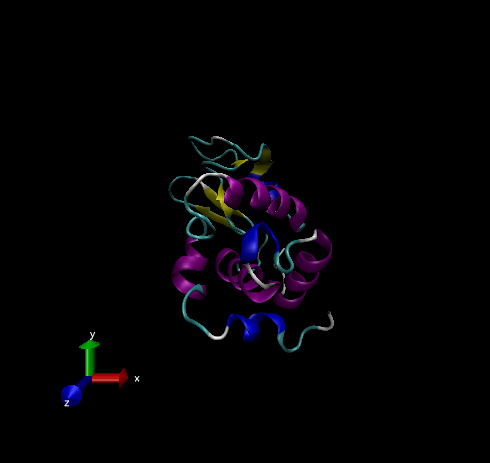

## **Step 2 - Choose a force field and generate the topology**

---
**What**: Convert the cleaned PDB coordinates into a complete molecular mechanics model.

**How**: gmx pdb2gmx matches residues and atoms to the CHARMM36 force field, adds missing hydrogen atoms, recognizes termini and disulfide bonds, and writes both coordinates and topology files.

**Why**: Coordinates alone cannot produce forces. GROMACS also needs atom types, masses, charges, bonded terms, and nonbonded parameters.

To keep consistancy we will use the same force field as in the original tutorial:
- **Force field**: CHARMM36, February 2026 release with CGenFF 5.0
- **Water model**: TIP3P

---

In [ ]:
# Downloads CHARMM36 force field for GROMACS
! wget -O charmm36.ff.tgz https://mackerell.umaryland.edu/download.php?filename=CHARMM_ff_params_files/charmm36-feb2026_cgenff-5.0.ff.tgz

# Extract it into the current working directory
! tar -xzf charmm36.ff.tgz

--2026-08-06 13:01:22--  https://mackerell.umaryland.edu/download.php?filename=CHARMM_ff_params_files/charmm36-feb2026_cgenff-5.0.ff.tgz
Resolving mackerell.umaryland.edu (mackerell.umaryland.edu)... 134.192.35.52
Connecting to mackerell.umaryland.edu (mackerell.umaryland.edu)|134.192.35.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1708921 (1.6M) [application/gzip]
Saving to: ‘charmm36.ff.tgz’

charmm36.ff.tgz     100%[===================>]   1.63M  2.25MB/s    in 0.7s    

2026-08-06 13:01:24 (2.25 MB/s) - ‘charmm36.ff.tgz’ saved [1708921/1708921]



In [ ]:
# This will generate chemicla topology needed to calculate forces during the simulation using our preferred force field
# echo "1" ensures that we choose CHARMM36 as our foce field
# - water tip3p ensures we are using TIP3P water model
! echo "1" | gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water tip3p

                     :-) GROMACS - gmx pdb2gmx, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water tip3p

Note that more recent versions of the CHARMM force field may be downloaded from
http://mackerell.umaryland.edu/charmm_ff.shtml#gromacs.

Select the Force Field:

From current directory:

 1: CHARMM all-atom force field

From '/usr/local/gromacs/share/gromacs/top':

 2: AMBER03 protein, nucleic AMBER94 (Duan et al., J. Comp. Chem. 24, 1999-2012, 2003)

 3: AMBER14SB protein (Maier, J. A. et al. JCTC 11, 3696–3713, 2015 / Miletic, V. et al. ChemRxiv, 2026)

 4: AMBER19SB protein (Tian, C. et al. JCTC 16, 528–552, 2020 / Miletic, V. et al. ChemRxiv, 2026)

 5: AMBER94 force field (Cornell et al., JACS 117, 5179-5197, 1995)

 6: AMBER96 protein, nucleic AMBER94 (Kollman et al., Acc. Chem. Res. 29, 461-469, 1996)

 7: AMBER99 protein, nucleic AMBER94 (Wang

<code>pdb2gmx</code> creates several linked files:

- <code>1AKI_processed.gro</code> : coordinates with added hydrogens
- <code>topol.top</code> : the system topology
- <code>posre.itp</code> : protein position restraints used during equilibration


<code>topol.top</code> is plain text. The optional cell below is useful for inspection, but do not edit it.

In [ ]:
# You can inspect generated chemical topolgy file
! sed -n '1,45p' topol.top
! tail -n 12 topol.top

;
;	File 'topol.top' was generated
;	By user: unknown (0)
;	On host: 5dfb74630e61
;	At date: Tue Aug  4 14:40:01 2026
;
;	This is a standalone topology file
;
;	Created by:
;	                    :-) GROMACS - gmx pdb2gmx, 2026.3 (-:
;	
;	Executable:   /usr/local/gromacs/bin/gmx
;	Data prefix:  /usr/local/gromacs
;	Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
;	Command line:
;	  gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water tip3p
;	Force field was read from current directory or a relative path - path added.
;

; Include forcefield parameters
#include "./charmm36-feb2026_cgenff-5.0.ff/forcefield.itp"

[ moleculetype ]
; Name            nrexcl
Protein_chain_A     3

[ atoms ]
;   nr       type  resnr residue  atom   cgnr     charge       mass  typeB    chargeB      massB
; residue   1 LYS rtp LYS  q +2.0
     1        NH3      1    LYS      N      1       -0.3     14.007
     2         HC      1    LYS     H1      2       0.33     

## **Step 3 - Define the periodic simulation box**
---
**What**: Center the protein in a cubic box with at least 1.2 nm between the protein and each box face.

**How**: `gmx editconf` changes the box vectors and translates the protein to the center.

**Why**: Periodic boundary conditions make the finite box behave like part of a bulk system. The solvent buffer also helps keep the protein from interacting directly with its own periodic image at the cutoff scale.

---

To simulate realistic biological conditions, we place the protein in a cubic box filled with water (`TIP3P`) and add counter-ions ($\text{Cl}^-$) to neutralize the net $+8e$ charge of Lysozyme.

In [ ]:
# Creates a cubic simulation box with a 1.2 nm buffer distance
! gmx editconf -f 1AKI_processed.gro -o 1AKI_newbox.gro -c -d 1.2 -bt cubic

                     :-) GROMACS - gmx editconf, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx editconf -f 1AKI_processed.gro -o 1AKI_newbox.gro -c -d 1.2 -bt cubic

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 1960 atoms
Volume: 123.376 nm^3, corresponds to roughly 55500 electrons
No velocities found
    system size :  3.817  4.234  3.454 (nm)
    diameter    :  5.010               (nm)
    center      :  2.781  2.488  0.017 (nm)
    box vectors :  5.906  6.845  3.052 (nm)
    box angles  :  90.00  90.00  90.00 (degrees)
    box volume  : 123.38               (nm^3)
    shift       :  0.924  1.217  3.688 (nm)
new center      :  3.705  3.705  3.705 (nm)
new box vectors :  7.410  7.410  7.410 (nm)
new box angles  :  90.00  90.00  90.00 (degrees)
new box volume  : 406.88               (nm^3)

GROMACS reminds you: "I Don't Like Dirt" (The Breeders)



In [ ]:
! gmx help

                       :-) GROMACS - gmx help, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx help

SYNOPSIS

gmx [-[no]h] [-[no]quiet] [-[no]version] [-[no]copyright] [-nice <int>]
    [-[no]backup]

OPTIONS

Other options:

 -[no]h                     (no)
           Print help and quit
 -[no]quiet                 (no)
           Do not print common startup info or quotes
 -[no]version               (no)
           Print extended version information and quit
 -[no]copyright             (no)
           Print copyright information on startup
 -nice   <int>              (19)
           Set the nicelevel (default depends on command)
 -[no]backup                (yes)
           Write backups if output files exist

Additional help is available on the following topics:
    commands    List of available commands
    selections  Selection syntax and usage
To access the help, use 'gmx help <topic>'.
For help on a

## **Step 4 - Solvate the protein**

---

**What**: Fill the empty volume around lysozyme with explicit water molecules.

**How**: `gmx solvate` inserts a pre-equilibrated water configuration, removes waters that overlap the protein, and updates the solvent count in topol.top.

**Why**: Solvent influences protein motion through collisions, electrostatics, hydrogen bonding, and hydrophobic solvation effects.

---

The coordinate template is named `spc216.gro`, but `gmx solvate uses` only its water geometry. The force-field topology generated earlier determines that these waters are treated as TIP3P.

In [ ]:
# we fill the box with water molecules
# -cp : takes box or solute coordinates
# -cs : solvent coordinate
# -p : it will update topo.top with number of inserted water molecules
! gmx solvate -cp 1AKI_newbox.gro -cs spc216.gro -o 1AKI_solv.gro -p topol.top

                     :-) GROMACS - gmx solvate, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx solvate -cp 1AKI_newbox.gro -cs spc216.gro -o 1AKI_solv.gro -p topol.top

Reading solute configuration
Reading solvent configuration

Initialising inter-atomic distances...

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

         The atomic radii are set according to:

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Ra

## **Step 5 - Neutralize the system with ions**

---

**What**: Replace water molecules with chloride ions until the system has zero net charge.

**How**: `gmx grompp` first combines parameters, coordinates, and topology into a binary run-input file (`ions.tpr`). `gmx genion` then replaces selected solvent molecules with ions and updates `topol.top`.

**Why**: Lysozyme has a net charge of +8 e in this protonation state. Eight Cl- counterions neutralize the simulation box, which is appropriate for the long-range electrostatics treatment used later.

---

`grompp` means GROMACS preprocessor. It performs consistency checks before a simulation or preparation step.

In [ ]:
# Downloads the short parameter file used for ion placement TPR
! wget -O ions.mdp http://www.mdtutorials.com/gmx/lysozyme/Files/ions.mdp

# Combines the ion parameter, solvated coordinates, and topology
! gmx grompp -f ions.mdp -c 1AKI_solv.gro -p topol.top -o ions.tpr

--2026-08-04 12:15:01--  http://www.mdtutorials.com/gmx/lysozyme/Files/ions.mdp
Resolving www.mdtutorials.com (www.mdtutorials.com)... 13.59.3.21
Connecting to www.mdtutorials.com (www.mdtutorials.com)|13.59.3.21|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1045 (1.0K)
Saving to: ‘ions.mdp’

ions.mdp            100%[===================>]   1.02K  --.-KB/s    in 0s      

2026-08-04 12:15:01 (193 MB/s) - ‘ions.mdp’ saved [1045/1045]

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx grompp -f ions.mdp -c 1AKI_solv.gro -p topol.top -o ions.tpr

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -848925705

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter

In [ ]:
# This step is performed to make total charge neutral by replacing water molecules with counterions
# Since our protein is positive net charge this will replace with Cl - ions as given by -nname
# if it had negative charge this will have replaced with NA ions as given by -pname
# echo "13" will select group 13 i.e. "SOL" as mentioned in tutorial
! echo "13" | gmx genion -s ions.tpr -o 1AKI_solv_ions.gro -p topol.top -pname NA -nname CL -neutral

                      :-) GROMACS - gmx genion, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx genion -s ions.tpr -o 1AKI_solv_ions.gro -p topol.top -pname NA -nname CL -neutral

Reading file ions.tpr, VERSION 2026.3 (single precision)
Reading file ions.tpr, VERSION 2026.3 (single precision)
Will try to add 0 NA ions and 8 CL ions.
Select a continuous group of solvent molecules
Group     0 (         System) has 39751 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   515 elements
Group     6 (   MainChain+Cb) has   632 elements
Group     7 (    MainChain+H) has   644 elements
Group     8 (      SideChain) has  1316 elements
Group     9 (    SideChain-H)

## **Things to keep in mind for the steps below**

**A useful GRMACS pattern : `grompp` then `mdrun`**


1. `gmx grompp` validates and compiles    an `.mdp` parameter file, coordinates, topology, and optional checkpoint into a `.tpr` run-input file.
2. `gmx mdrun` executes the calculation described by that `.tpr` file.  

Besides these two command you will also encounter new file type this table will help you:
| Extension | Meaning |
|---|---|
| `.gro` | Coordinates, usually the final frame |
| `.tpr` | Compiled run input, including parameters and reference coordinates |
| `.xtc` | Compressed trajectory coordinates |
| `.edr` | Energies and thermodynamic quantities |
| `.cpt` | Checkpoint containing state needed to continue a run |
| `.log` | Detailed run log |
| `.xvg` | Text data produced by analysis tools |


In [ ]:
# This is just a helper function that will help us visualize the graphs here within colab
import matplotlib.pyplot as plt
from pathlib import Path

# Helper function to parse GROMACS .xvg files
def read_xvg(filename):
    x, y = [], []
    with open(filename, 'r') as f:
        for line in f:
            # Skip header lines starting with @ or #
            if not line.startswith(('@', '#')):
                cols = line.split()
                if len(cols) >= 2:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
    return x, y


# Ploting
def plot_xvg(filename, title, xlabel, ylabel, target=None, color="tab:blue"):
    # Plot a two-column XVG file and optionally draw a target line.
    x_values, y_values = read_xvg(filename)
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, color=color, linewidth=1.2)
    if target is not None:
        plt.axhline(target, color="black", linestyle="--", alpha=0.7, label=f"Target: {target}")
        plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    # Save the figure directly before showing it
    png_filename = Path(filename).with_suffix(".png")
    plt.savefig(png_filename, dpi=300, bbox_inches="tight", facecolor="white")

    plt.show()
    print(f"Plot saved: {png_filename}")
    plt.close()

##**Step 6 - Energy minimization**

---

**What**: Relax the starting coordinates without simulating physical time.

**How**: The steepest-descents algorithm moves atoms downhill on the potential-energy surface until the maximum force is below the chosen tolerance or the step limit is reached.

**Why**: Solvation and ion insertion can create close contacts and very large repulsive forces. Starting dynamics from such a geometry can cause numerical instability.

----

Just keep in mind that energy minimization is not equilibration and does not prove that the protein is at its global minimum. It is a local geometry-relaxation step, and aids our calculation by avoiding infinity(too big) and infinitesimal(too small).


In [ ]:
# Like before we download the energy minimization parameters file named minim.mdp
! wget -O minim.mdp http://www.mdtutorials.com/gmx/lysozyme/Files/minim.mdp

# Build em.tpr from the neutralized system and its topology
! gmx grompp -f minim.mdp -c 1AKI_solv_ions.gro -p topol.top -o em.tpr

--2026-08-04 12:16:43--  http://www.mdtutorials.com/gmx/lysozyme/Files/minim.mdp
Resolving www.mdtutorials.com (www.mdtutorials.com)... 13.59.3.21
Connecting to www.mdtutorials.com (www.mdtutorials.com)|13.59.3.21|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1045 (1.0K)
Saving to: ‘minim.mdp’

minim.mdp           100%[===================>]   1.02K  --.-KB/s    in 0s      

2026-08-04 12:16:43 (212 MB/s) - ‘minim.mdp’ saved [1045/1045]

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx grompp -f minim.mdp -c 1AKI_solv_ions.gro -p topol.top -o em.tpr

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -339806242

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 pa

In [ ]:
# This will run Steepest Descents Energy Minimization on GPU
# here -deffnm em gives all output files base name em and -nb gpu enforces gpu calculation
! gmx mdrun -v -deffnm em -nb gpu

                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx mdrun -v -deffnm em -nb gpu

Reading file em.tpr, VERSION 2026.3 (single precision)
1 GPU selected for this run.
Mapping of GPU IDs to the 1 GPU task in the 1 rank on this node:
  PP:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the CPU
Using 1 MPI thread
Using 12 OpenMP threads 


Steepest Descents:
   Tolerance (Fmax)   =  1.00000e+03
   Number of steps    =        50000
Step=    0, Dmax= 1.0e-02 nm, Epot= -4.56123e+05 Fmax= 1.81016e+05, atom= 1891
Step=    1, Dmax= 1.0e-02 nm, Epot= -4.68149e+05 Fmax= 6.69837e+04, atom= 936
Step=    2, Dmax= 1.2e-02 nm, Epot= -4.81466e+05 Fmax= 2.92711e+04, atom= 19487
Step=    3, Dmax= 1.4e-02 nm, Epot= -4.94261e+05 Fmax= 1.37322e+04, ato

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx energy -f em.edr -o potential.xvg

Opened em.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Potential       12  Pressure      
 13  Vir-XX          14  Vir-XY          15  Vir-XZ          16  Vir-YX        
 17  Vir-YY          18  Vir-YZ          19  Vir-ZX          20  Vir-ZY        
 21  Vir-ZZ          22  Pres-XX    

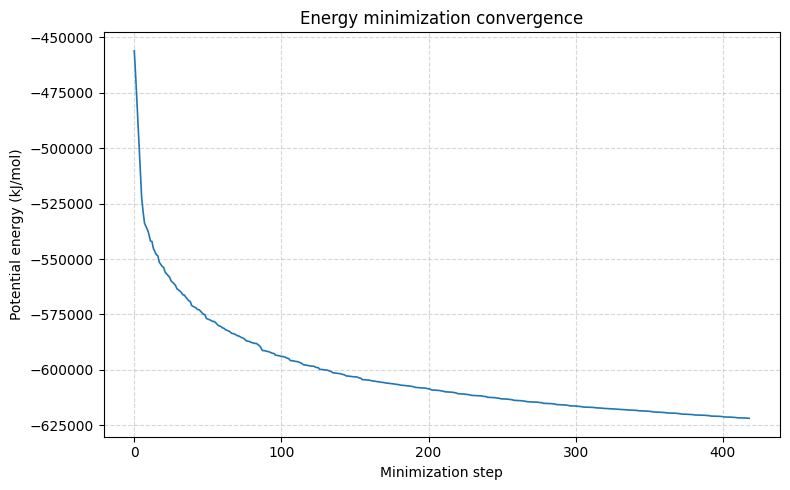

Plot saved: potential.png


In [ ]:
# Plots Energy Minimization Convergence
# as usual echo "11 0" will choose option 11 and option 0
! echo "11 0" | gmx energy -f em.edr -o potential.xvg

plot_xvg(
    "potential.xvg",
    "Energy minimization convergence",
    "Minimization step",
    "Potential energy (kJ/mol)",
)

### **Things to note** :
The GROMACS log should state that steepest descents converge to `Fmax < 1000` kJ/(mol nm), and the final potential energy should be negative. The plot should drop overall before leveling. If the maximum force remains above the tolerance, do not begin NVT until the geometry or minimization setup has been examined.

You can record:
- Final potential energy: __________ kJ/mol which should be negative
- Maximum force: __________ kJ/(mol nm) which should be less than `Fmax`
- Number of minimization steps: __________

## **Step 7 - NVT equilibration: stabilize temperature**
---

**What**: Equilibrate the minimized system for 100 ps at a target temperature of 298 K while keeping the number of particles and box volume fixed.

**How**: The V-rescale thermostat controls temperature. Position restraints keep the protein heavy atoms near the starting structure while water and ions reorganize around it.

**Why**: Velocities and solvent organization must adjust gradually before an unrestrained production run.

----

In `grompp`, `-r em.gro` provides the reference coordinates for position restraints.

In [ ]:
# Preparing and running 100 ps of NVT equilibration at 298 K.
! wget -O nvt.mdp http://www.mdtutorials.com/gmx/lysozyme/Files/nvt.mdp
! gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr
! gmx mdrun -deffnm nvt -nb gpu

--2026-08-04 12:17:14--  http://www.mdtutorials.com/gmx/lysozyme/Files/nvt.mdp
Resolving www.mdtutorials.com (www.mdtutorials.com)... 13.59.3.21
Connecting to www.mdtutorials.com (www.mdtutorials.com)|13.59.3.21|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2316 (2.3K)
Saving to: ‘nvt.mdp’

nvt.mdp             100%[===================>]   2.26K  --.-KB/s    in 0s      

2026-08-04 12:17:14 (446 MB/s) - ‘nvt.mdp’ saved [2316/2316]

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -675287565

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx energy -f nvt.edr -o temperature.xvg

Opened nvt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pressure        18  Constr.-rmsd    19  Vir-XX          20  Vir-XY        
 21  Vir-XZ          22  Vir-YX 

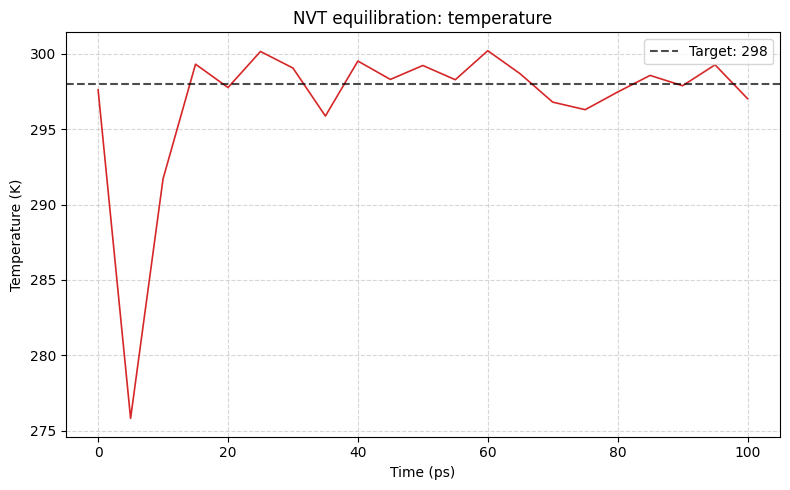

Plot saved: temperature.png


In [ ]:
# this will perform similar functinality as above and plot temperature vs time graph
! echo "16 0" | gmx energy -f nvt.edr -o temperature.xvg

plot_xvg(
    "temperature.xvg",
    "NVT equilibration: temperature",
    "Time (ps)",
    "Temperature (K)",
    target=298,
    color="tab:red",
)

## **Step 8 - NPT equilibration: stabilize pressure and density**
---

**What**: Continue equilibration for 500 ps at 298 K and 1 bar while allowing the box volume to change.

**How**: The thermostat maintains temperature and the C-rescale barostat adjusts the box to approach the target pressure and density. `-t nvt.cpt` carries forward velocities and state from NVT.

**Why**: A solvated box built from geometry is not automatically at the correct equilibrium density. NPT prepares an appropriate volume before production.

---

Instantaneous pressure in a small molecular system is noisy and can fluctuate by hundreds of bar. A stable density and a reasonable time-averaged pressure are more informative than expecting a flat pressure trace.

In [ ]:
# Preparing and running 500 ps of NPT equilibration.
! wget -O npt.mdp http://www.mdtutorials.com/gmx/lysozyme/Files/npt.mdp
! gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr
! gmx mdrun -deffnm npt -nb gpu

--2026-08-04 12:18:27--  http://www.mdtutorials.com/gmx/lysozyme/Files/npt.mdp
Resolving www.mdtutorials.com (www.mdtutorials.com)... 13.59.3.21
Connecting to www.mdtutorials.com (www.mdtutorials.com)|13.59.3.21|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2412 (2.4K)
Saving to: ‘npt.mdp’

npt.mdp             100%[===================>]   2.36K  --.-KB/s    in 0s      

2026-08-04 12:18:27 (448 MB/s) - ‘npt.mdp’ saved [2412/2412]

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -8404226

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1


                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx energy -f npt.edr -o pressure.xvg

Opened npt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pressure        18  Constr.-rmsd    19  Box-X           20  Box-Y         
 21  Box-Z           22  Volume    

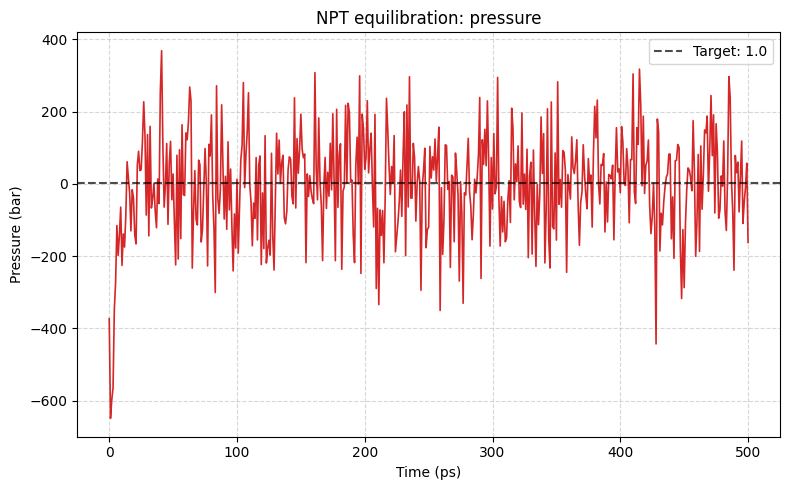

Plot saved: pressure.png


In [ ]:
# extracting pressure data and ploting
! echo "17 0" | gmx energy -f npt.edr -o pressure.xvg

plot_xvg(
    "pressure.xvg",
    "NPT equilibration: pressure",
    "Time (ps)",
    "Pressure (bar)",
    target=1.0,
    color="tab:red",
)

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx energy -f npt.edr -o density.xvg

Opened npt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pressure        18  Constr.-rmsd    19  Box-X           20  Box-Y         
 21  Box-Z           22  Volume     

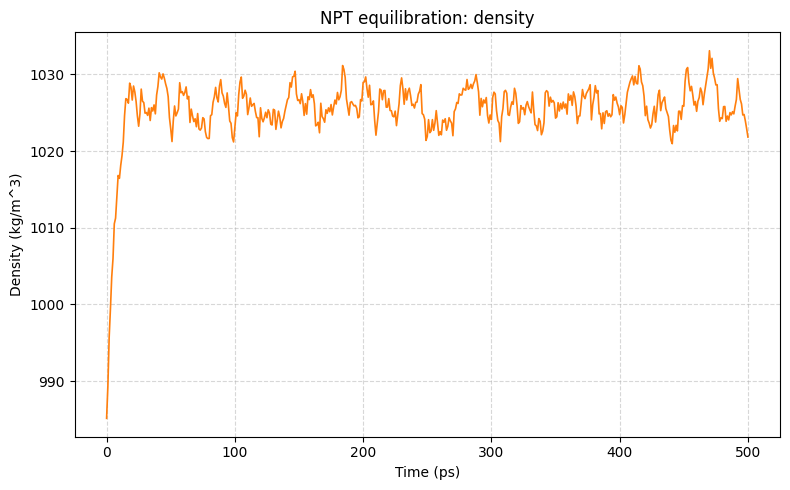

Plot saved: density.png


In [ ]:
! echo "23 0" | gmx energy -f npt.edr -o density.xvg
plot_xvg(
    "density.xvg",
    "NPT equilibration: density",
    "Time (ps)",
    "Density (kg/m^3)",
    color="tab:orange",
)

### **Things to note**:
The density should settle to a roughly stable band; a value near 1025 kg/m^3 is expected for this tutorial system. Pressure should fluctuate around its target over time, not form a flat line.



## **Step 9 - Production molecular dynamics**
---

**What**: Run 10 ns of production MD and record the trajectory used for analysis.

**How**: `grompp` starts from the NPT coordinates and checkpoint. The production parameter file removes the equilibration position restraints, and `mdrun` integrates the equations of motion for 5,000,000 steps.

**Why**: Only after minimization and equilibration do we collect motion intended for scientific analysis.

---

This is the longest stage and may take about 1 to 1.5 hours on a Colab T4, although timing varies. Keep the Colab session connected. The runtime files are temporary until downloaded.

In [ ]:
# This will take up to 1 - 1.5 hours to complete
# Here we are fetching parameters and then running simulation
from pathlib import Path
cpt_file = Path("md_0_10.cpt")
log_file = Path("md_0_10.log")
xtc_file = Path("md_0_10.xtc")
edr_file = Path("md_0_10.edr")

if not Path("md_0_10.tpr").exists():
    !wget -O md.mdp http://www.mdtutorials.com/gmx/lysozyme/Files/md.mdp
    !gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -o md_0_10.tpr
else:
    print("Using the saved md_0_10.tpr file.")

if cpt_file.exists() and log_file.exists() and  xtc_file.exists() and edr_file.exists():
    print("Checkpoint found. Resuming MD")
    # Run this if your simulations stops
    !gmx mdrun -deffnm production -nb gpu -cpi production.cpt -append -cpt 5 -v
else:
  if cpt_file.exists():
    print("Incomplete run detected but mising other files so starting fresh agian")
    cpt_file.unlink()
    print("No checkpoint found. Starting MD")
    !gmx mdrun -deffnm md_0_10 -nb gpu -cpt 5 -v

Using the saved md_0_10.tpr file.
Checkpoint found. Resuming MD
                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx mdrun -deffnm md_0_10 -nb gpu -cpi md_0_10.cpt -append -cpt 5 -v

Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Changing nstlist from 10 to 100, rlist from 1.2 to 1.352

1 GPU selected for this run.
Mapping of GPU IDs to the 2 GPU tasks in the 1 rank on this node:
  PP:0,PME:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the GPU
PME tasks will do all aspects on the GPU
Using 1 MPI thread
Using 12 OpenMP threads 

starting mdrun 'LYSOZYME in water'
5000000 steps,  10000.0 ps (continuing from step 4910101,   9820.2 ps).
step 4922600: timed with pme grid 48 48 48, coulomb cutoff 1.200: 318.8 M-cycles
st

In [ ]:
!gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -o production.tpr


                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -o production.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to 2146938589

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

NOTE 1 [file topol.top, line 18485]:
  System has non-zero total charge: 8.000000
  Total charge should normally be an integer. See
  https://manual.gromacs.org/current/user-guide/floating-point.html
  for discussion on how close it should be to an integer.




WARNING 1 [file topol.top, line 18485]:
  Y

In [ ]:
! nohup gmx mdrun -deffnm md_0_10 -nb gpu -pme gpu -bonded gpu -cpt 5 -v > simulation.log 2>&1 &

In [ ]:
!tail -f simulation.log

NOTE: 10 % of the run time was spent in pair search,
      you might want to increase nstlist (this has no effect on accuracy)

               Core t (s)   Wall t (s)        (%)
       Time:     2845.154      237.103     1200.0
                 (ns/day)    (hour/ns)    (ms/step)  (Matom*steps/s) 
Performance:      285.107        0.084        0.606           65.560 

GROMACS reminds you: "If Java had true garbage collection, most programs would delete themselves upon execution." (Robert Sewell)

^C


In [ ]:
! unminimize
y


This system has been minimized by removing packages and content that are
not required on a system that users do not log into.

This script restores content and packages that are found on a default
Ubuntu server system in order to make this system more suitable for
interactive use.

Reinstallation of packages may fail due to changes to the system
configuration, the presence of third-party packages, or for other
reasons.

This operation may take some time.

Would you like to continue? [y/N] y



In [ ]:
!

/content


### **Things to note**:
Confirm that `mdrun` reaches 10,000 ps and writes final coordinates. The files `md_0_10.xtc`, `md_0_10.edr`, `md_0_10.gro`, `md_0_10.cpt`, and `md_0_10.log` should exist. A completed run is not the same as a converged scientific result; convergence must be assessed for the quantity being studied.

## **Step 10 - Remove periodic-boundary(PBC) visualization artifacts**
---

**What**: Make molecules whole and keep the protein centered in the box.

**How**: `gmx trjconv -pbc mol -center` reconstructs molecules split across periodic boundaries and recenters each frame. We select `Protein` for centering and `System` for output.

**Why**: Periodic coordinates can make a continuous protein look broken or make molecules jump across the display. Cleaning changes the representation of coordinates, not the underlying dynamics.

---

The two menu selections are supplied automatically below: group 1 (`Protein`) followed by group 0 (`System`).

In [ ]:
# This will center the protein for visualization and will treat PBC# echo "1 0" |
! gmx trjconv -s md_0_10.tpr -f md_0_10.xtc -o md_0_10_noPBC.gro -pbc whole

                     :-) GROMACS - gmx trjconv, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx trjconv -s md_0_10.tpr -f md_0_10.xtc -o md_0_10_noPBC.gro -pbc whole

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write gro: Coordinate file in Gromos-87 format
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Select group for output
Group     0 (         System) has 39735 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   515 elements
Group     6 (   MainChain+Cb) has   632 elements
Group     7 (    MainChain+H) has   644 elements
Grou

In [ ]:
! gmx trjconv -h

                     :-) GROMACS - gmx trjconv, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx trjconv -h

SYNOPSIS

gmx trjconv [-f [<.xtc/.trr/...>]] [-s [<.tpr/.gro/...>]] [-n [<.ndx>]]
            [-fr [<.ndx>]] [-sub [<.ndx>]] [-drop [<.xvg>]]
            [-o [<.xtc/.trr/...>]] [-b <time>] [-e <time>] [-tu <enum>]
            [-[no]w] [-xvg <enum>] [-skip <int>] [-dt <time>] [-[no]round]
            [-dump <time>] [-t0 <time>] [-timestep <time>] [-pbc <enum>]
            [-ur <enum>] [-[no]center] [-boxcenter <enum>] [-box <vector>]
            [-trans <vector>] [-shift <vector>] [-fit <enum>] [-ndec <int>]
            [-[no]vel] [-[no]force] [-trunc <time>] [-exec <string>]
            [-split <time>] [-[no]sep] [-nzero <int>] [-dropunder <real>]
            [-dropover <real>] [-[no]conect]

DESCRIPTION

gmx trjconv can convert traje

## **Step 11 - Structural analysis**
---

No single measurement answers whether a protein is "stable." We combine complementary observables:

- **Backbone RMSD**: Deviation after rotational and translational fitting. A plateau can indicate sampling around a consistent conformational region, but RMSD alone does not prove convergence.

- **Radius of gyration (Rg)**: Overall compactness. It does not identify which region changed.

- **DSSP secondary structure**: Assignment of helices, strands, turns, and coils over time.

- **Hydrogen bonds**: Geometric counts for selected donor and acceptor groups. Counts depend on the command's geometric criteria and should be interpreted comparatively.

---

Each XTC frame is compared with information in a matching TPR file. The XTC stores coordinates but not the full topology.

## **Backbone RMSD**
The first command uses the production run input as its reference. The second uses `em.tpr`, whose coordinates came from the neutralized, pre-minimization starting system.

In [ ]:
# Backbone fit (4), then Backbone RMSD calculation (4).
! echo "4 4" | gmx rms -s md_0_10.tpr -f md_0_10_noPBC.xtc -o rmsd.xvg -tu ns

# Compare the trajectory with the processed starting structure in em.tpr.
! echo "4 4" | gmx rms -s em.tpr -f md_0_10_noPBC.xtc -o rmsd_xtal.xvg -tu ns


                       :-) GROMACS - gmx rms, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx rms -s md_0_10.tpr -f md_0_10_noPBC.xtc -o rmsd.xvg -tu ns

Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Select group for least squares fit
Group     0 (         System) has 39735 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   515 elements
Group     6 (   MainChain+Cb) has   632 elements
Group     7 (    MainChain+H) has   644 elements
Group     8 (      SideChain) has  1316 elements
Group     9 (    SideChain-H) has   486 elements
Group    10 (    Prot-Masses) has  1960 elements
Grou

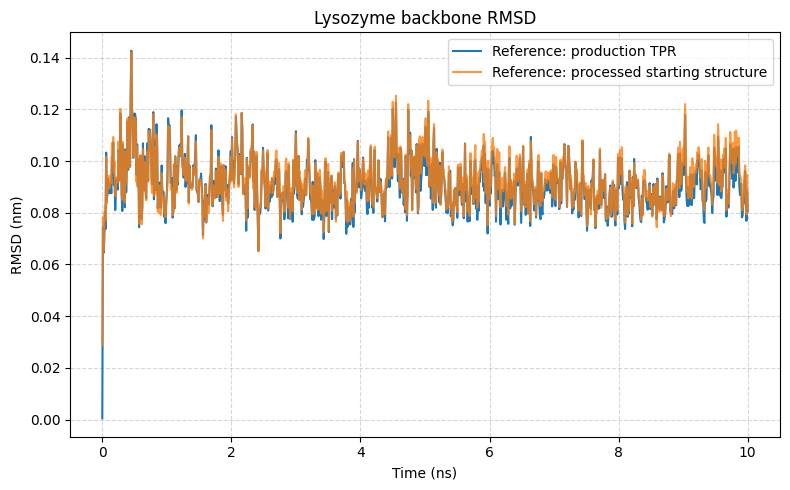

In [ ]:
# Visualize both RMSD definitions on one graph and save it
time_prod, rmsd_prod = read_xvg("rmsd.xvg")
time_start, rmsd_start = read_xvg("rmsd_xtal.xvg")

plt.figure(figsize=(8, 5))
plt.plot(time_prod, rmsd_prod, label="Reference: production TPR")
plt.plot(time_start, rmsd_start, label="Reference: processed starting structure", alpha=0.8)
plt.title("Lysozyme backbone RMSD")
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("RMSD.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()


### **Radius of gyration**
`gmx gyrate` calculates the mass-weighted spatial distribution of the protein around its center of mass. A persistent large shift can indicate expansion or compaction, while small fluctuations are normal.

                      :-) GROMACS - gmx gyrate, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx gyrate -s md_0_10.tpr -f md_0_10_noPBC.xtc -o gyrate.xvg -sel Protein -tu ns

Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Last frame       1000 time   10.000   
Analyzed 1001 frames, last time 10000.000

GROMACS reminds you: "You Leave Me Dry" (P.J. Harvey)



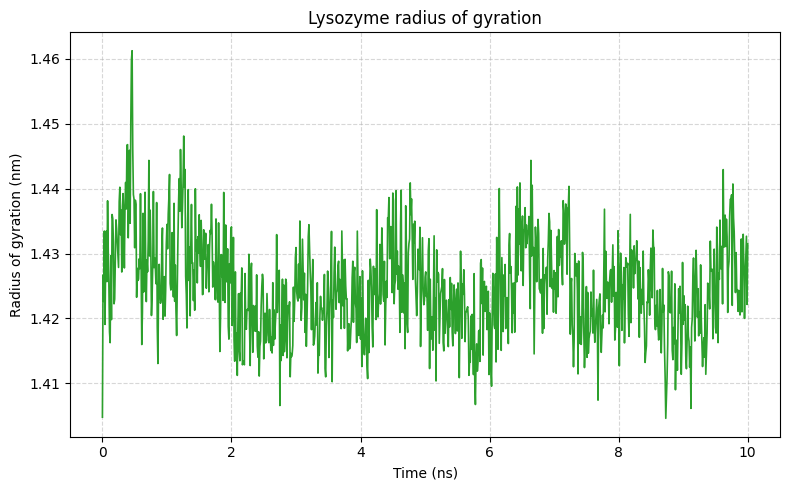

Plot saved: gyrate.png


In [ ]:
!gmx gyrate -s md_0_10.tpr -f md_0_10_noPBC.xtc -o gyrate.xvg -sel Protein -tu ns

plot_xvg(
    "gyrate.xvg",
    "Lysozyme radius of gyration",
    "Time (ns)",
    "Radius of gyration (nm)",
    color="tab:green",
)

##**Secondary structure with DSSP**
DSSP assigns secondary structure from backbone geometry and hydrogen-bond patterns. This connects the trajectory to the alpha helices, beta strands, and loops discussed in the presentation.

In [ ]:
# Writes per-residue assignments to dssp.dat and counts to dssp_num.xvg.
! gmx dssp -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -o dssp.dat -num dssp_num.xvg -sel Protein -nb gpu

                       :-) GROMACS - gmx dssp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx dssp -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -o dssp.dat -num dssp_num.xvg -sel Protein

Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Last frame       1000 time   10.000   
Analyzed 1001 frames, last time 10000.000

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
W. Kabsch, C. Sander
Dictionary of protein secondary structure: pattern recognition of
hydrogen-bonded and geometrical features
Biopolymers (1983)
https://doi.org/10.1002/bip.360221211
-------- -------- --- Thank You --- -------- --------


++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
S. Gorelov, A. Titov, O. Tolicheva, A. Konevega, A. Shvetsov
DSSP in GROMACS: Tool for Defining Secondary Struct

## **Hydrogen Bonds**

In [ ]:
! echo -e "7\n7" | gmx hbond -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -num hbnum_mainchain.xvg

                      :-) GROMACS - gmx hbond, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx hbond -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -num hbnum_mainchain.xvg

Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)

Checking for overlap in atoms between MainChain+H (644 atoms) and MainChain+H (644 atoms)
Selection 'MainChain+H' has 257 acceptors and 127 donors.
Last frame       1000 time   10.000   
Analyzed 1001 frames, last time 10000.000

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
S. Gorelov, A. Titov, O. Tolicheva, A. Konevega, A. Shvetsov
Determination of Hydrogen Bonds in GROMACS: A New Implementation to Overcome
Memory Limitation
Journal of Chemical Information and Modeling (2024)
https://doi.org/10.1021/acs.jcim.3c02087
-------- -------- --- Thank

In [ ]:
! echo -e "8\n8" | gmx hbond -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -num hbnum_sidechain.xvg

                      :-) GROMACS - gmx hbond, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx hbond -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -num hbnum_sidechain.xvg

Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)

Checking for overlap in atoms between SideChain (1316 atoms) and SideChain (1316 atoms)
Selection 'SideChain' has 121 acceptors and 83 donors.

Back Off! I just backed up hbond.ndx to ./#hbond.ndx.1#
Last frame       1000 time   10.000   
Analyzed 1001 frames, last time 10000.000

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
S. Gorelov, A. Titov, O. Tolicheva, A. Konevega, A. Shvetsov
Determination of Hydrogen Bonds in GROMACS: A New Implementation to Overcome
Memory Limitation
Journal of Chemical Information and Modeling (2024)
https://doi.org/

In [ ]:
! echo -e "1\n13" | gmx hbond -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -num hbnum_prot_wat.xvg

                      :-) GROMACS - gmx hbond, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation/Lysozyme
Command line:
  gmx hbond -s md_0_10.tpr -f md_0_10_noPBC.xtc -tu ns -num hbnum_prot_wat.xvg

Reading file md_0_10.tpr, VERSION 2026.3 (single precision)
Reading file md_0_10.tpr, VERSION 2026.3 (single precision)

Checking for overlap in atoms between Protein (1960 atoms) and SOL (37767 atoms)
Selection 'Protein' has 378 acceptors and 210 donors.
Selection 'SOL' has 12589 acceptors and 12589 donors.

Back Off! I just backed up hbond.ndx to ./#hbond.ndx.2#
Last frame       1000 time   10.000   
Analyzed 1001 frames, last time 10000.000

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
S. Gorelov, A. Titov, O. Tolicheva, A. Konevega, A. Shvetsov
Determination of Hydrogen Bonds in GROMACS: A New Implementation to Overcome
Memory Limitation
Journal of Chemical Inf

## **Step 12 - Download files for VMD and your lab record**
---

VMD needs both a structure file and a trajectory file:

- `md_0_10.gro` supplies atom names, order, and a coordinate frame.
- `md_0_10_noPBC.xtc` supplies the cleaned time series.

In VMD, load `md_0_10.gro` first. Then choose Load Data Into Molecule and load `md_0_10_noPBC.xtc`. For a PyMOL-like protein view, use Drawing Method: NewCartoon and Coloring Method: Structure.

The next cell creates one ZIP archive containing the essential visualization files, simulation record, and analysis outputs. Download it before your Colab runtime ends.

In [ ]:
import shutil
from google.colab import files

# 1. Compress the current working directory into Lysozyme.zip
shutil.make_archive('/content/Lysozyme', 'zip', '.')

# 2. Trigger the file download
files.download('/content/Lysozyme.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

! ls


 1AKI_clean.pdb			  hbnum_sidechain.xvg   npt.trr
 1AKI_newbox.gro		  hbond.ndx	        nvt.cpt
 1AKI.pdb			 '#hbond.ndx.1#'        nvt.edr
 1AKI_processed.gro		 '#hbond.ndx.2#'        nvt.gro
 1AKI_solv.gro			 '#hbond.ndx.3#'        nvt.log
 1AKI_solv_ions.gro		  ions.mdp	        nvt.mdp
 BRFP_lysozyme_results.zip	  ions.tpr	        nvt.tpr
 charmm36-feb2026_cgenff-5.0.ff   md_0_10.cpt	        nvt.trr
 charmm36.ff.tgz		  md_0_10.edr	        posre.itp
 density.png			  md_0_10.gro	        potential.png
 density.xvg			  md_0_10.log	        potential.xvg
 dssp.dat			  md_0_10_noPBC.xtc     pressure.png
 dssp_num.xvg			  md_0_10_prev.cpt      pressure.xvg
 em.edr				  md_0_10.tpr	        RMSD.png
 em.gro				  md_0_10.xtc	        rmsd_xtal.xvg
 em.log				  md.mdp	        rmsd.xvg
 em.tpr				  mdout.mdp	        script.sh
 em.trr				  minim.mdp	        SHA256SUMS.txt
 gromacs_cuda_build.tar.gz	  npt.cpt	        temperature.png
 gyrate.png			  npt.edr	        temperature.xvg
 gyrate.xvg			  np

In [ ]:
! cat pressure.xvg | grep -i '[0-9]'| grep -v '^#' | grep -v "^@" | tr -s  ' '| cut -d" " -f2,3 | tr ' ' , > pressure.csv

In [ ]:
! head pressure.csv

0.000000,-581.305481
1.000000,-658.687927
2.000000,-640.123474
3.000000,-628.003235
4.000000,-292.935455
5.000000,-286.557068
6.000000,-272.609131
7.000000,-88.479736
8.000000,-1.971964
9.000000,-363.797974


# **Now Its your turn to create a simulation**